In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wikiart30k/wikiart_test.txt
/kaggle/input/wikiart30k/wikiart_train.txt
/kaggle/input/wikiart30k/Pop_Art/nicholas-krushenick_untitled-1963.jpg
/kaggle/input/wikiart30k/Pop_Art/andy-warhol_coca-cola.jpg
/kaggle/input/wikiart30k/Pop_Art/leroy-neiman_john-elway-1999.jpg
/kaggle/input/wikiart30k/Pop_Art/andy-warhol_frog.jpg
/kaggle/input/wikiart30k/Pop_Art/r.-b.-kitaj_if-not-not.jpg
/kaggle/input/wikiart30k/Pop_Art/andy-warhol_marilyn-1.jpg
/kaggle/input/wikiart30k/Pop_Art/patrick-caulfield_sweet-bowl-1967.jpg
/kaggle/input/wikiart30k/Pop_Art/peter-phillips_custom-print-no-ii-1965.jpg
/kaggle/input/wikiart30k/Pop_Art/yayoi-kusama_pumpkin-1983.jpg
/kaggle/input/wikiart30k/Pop_Art/richard-hamilton_maps-of-palestine.jpg
/kaggle/input/wikiart30k/Pop_Art/robert-indiana_four-winds-from-1-cent-life-portfolio-1964.jpg
/kaggle/input/wikiart30k/Pop_Art/eduardo-paolozzi_cyclops-1958.jpg
/kaggle/input/wikiart30k/Pop_Art/richard-hamilton_patricia-knight-ii-1982.jpg
/kaggle/input/wikiart30k

In [2]:
import numpy as np
import pandas as pd
import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch.nn as nn
from torchvision.models import swin_t, Swin_T_Weights


In [3]:
DATA_DIR = "/kaggle/input/wikiart30k"

classes = sorted(os.listdir(DATA_DIR))
len(classes), classes[:10]


(29,
 ['Abstract_Expressionism',
  'Action_painting',
  'Analytical_Cubism',
  'Art_Nouveau_Modern',
  'Baroque',
  'Color_Field_Painting',
  'Contemporary_Realism',
  'Cubism',
  'Early_Renaissance',
  'Expressionism'])

In [4]:
import os

base = "/kaggle/input/wikiart30k"

for style in os.listdir(base):
    path = os.path.join(base, style)
    if os.path.isdir(path):
        print(style, ":", os.listdir(path)[:2])


Pop_Art : ['nicholas-krushenick_untitled-1963.jpg', 'andy-warhol_coca-cola.jpg']
Minimalism : ['richard-serra_one-ton-prop-house-of-cards-1969.jpg', 'eva-hesse_untitled-1968.jpg']
Color_Field_Painting : ['mark-rothko_black-on-maroon-4.jpg', 'ian-davenport_poured-lines-orange-2005.jpg']
Mannerism_Late_Renaissance : ['el-greco_portrait-of-juan-alfonso-de-pimentel-y-herrera.jpg', 'tintoretto_the-battle-of-zara.jpg']
Symbolism : ['lovis-corinth_paradise-1911.jpg', 'konstantin-vasilyev_in-another-window.jpg']
Impressionism : ['konstantin-korovin_roses-and-violets-1912.jpg', 'camille-pissarro_the-tedder-1884.jpg']
Contemporary_Realism : ['jamie-wyeth_mushroom-picker-1963.jpg', 'konstantin-vasilyev_not-detected-272814.jpg']
High_Renaissance : ['raphael_the-healing-of-the-lame-man-cartoon-for-the-sistine-chapel.jpg', 'andrea-mantegna_molorchos-making-a-sacrifice-to-hercules-1506.jpg']
Fauvism : ['pyotr-konchalovsky_still-life-with-red-gladioli-1915.jpg', 'fikret-mualla-saygi_unknown-title-5.jp

In [5]:
from pathlib import Path
import random
from collections import defaultdict
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image

DATA_DIR = Path('/kaggle/input/wikiart30k')
VAL_SPLIT = 0.1
MIN_IMAGES_PER_ARTIST = 10
NUM_SELECTED_ARTISTS = 10  


artist_images = defaultdict(list)

for style_dir in DATA_DIR.iterdir():
    if not style_dir.is_dir():
        continue
    for img_path in style_dir.glob('*.jpg'):
        artist = img_path.name.split('_')[0].strip()
        if artist == "":
            continue
        artist_images[artist].append(img_path)


valid_artists = [a for a, imgs in artist_images.items() if len(imgs) >= MIN_IMAGES_PER_ARTIST]
selected_artists = valid_artists[:NUM_SELECTED_ARTISTS]   

print("Selected 10 Artists:")
print(selected_artists)


artist_images = {artist: artist_images[artist] for artist in selected_artists}


all_images = []
all_labels = []
artist2idx = {}
idx = 0
train_indices = []
val_indices = []

for artist in selected_artists:
    images = artist_images[artist]

    artist2idx[artist] = idx
    idx += 1

    random.shuffle(images)
    n_val = int(len(images) * VAL_SPLIT)

    start_idx = len(all_images)
    all_images.extend(images)
    all_labels.extend([artist2idx[artist]] * len(images))

    val_indices.extend(range(start_idx, start_idx + n_val))
    train_indices.extend(range(start_idx + n_val, start_idx + len(images)))

print(f"Total images: {len(all_images)}")
print(f"Train size: {len(train_indices)}, Val size: {len(val_indices)}")
print(f"artist2idx mapping: {artist2idx}")


class WikiArtDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = WikiArtDataset(all_images, all_labels, transform=transform)


train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


Selected 10 Artists:
['andy-warhol', 'r.-b.-kitaj', 'patrick-caulfield', 'yayoi-kusama', 'richard-hamilton', 'robert-indiana', 'gerard-fromanger', 'walter-battiss', 'roy-lichtenstein', 'hiro-yamagata']
Total images: 247
Train size: 225, Val size: 22
artist2idx mapping: {'andy-warhol': 0, 'r.-b.-kitaj': 1, 'patrick-caulfield': 2, 'yayoi-kusama': 3, 'richard-hamilton': 4, 'robert-indiana': 5, 'gerard-fromanger': 6, 'walter-battiss': 7, 'roy-lichtenstein': 8, 'hiro-yamagata': 9}


In [6]:
import shutil
from pathlib import Path

train_dir = Path("/kaggle/working/train")
val_dir = Path("/kaggle/working/val")


if train_dir.exists():
    shutil.rmtree(train_dir)
if val_dir.exists():
    shutil.rmtree(val_dir)


In [7]:
#pip install --upgrade torchvision


In [8]:
from pathlib import Path
import random
from collections import defaultdict
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler
from PIL import Image
import torch

DATA_DIR = Path('/kaggle/input/wikiart30k')
VAL_SPLIT = 0.1
MIN_IMAGES_PER_ARTIST = 10
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_SELECTED_ARTISTS = 10   


artist_images = defaultdict(list)

for style_dir in DATA_DIR.iterdir():
    if not style_dir.is_dir():
        continue
    for img_path in style_dir.glob('*.jpg'):
        artist = img_path.name.split('_')[0].strip()
        if artist == "":
            continue
        artist_images[artist].append(img_path)


valid_artists = [a for a, imgs in artist_images.items() if len(imgs) >= MIN_IMAGES_PER_ARTIST]
selected_artists = valid_artists[:NUM_SELECTED_ARTISTS]

print(f"Selected artists ({len(selected_artists)}):")
print(selected_artists)


artist_images = {artist: artist_images[artist] for artist in selected_artists}


all_images = []
all_labels = []
artist2idx = {}
idx = 0
train_indices = []
val_indices = []

for artist in selected_artists:
    images = artist_images[artist]
    artist2idx[artist] = idx
    idx += 1

    random.shuffle(images)
    n_val = int(len(images) * VAL_SPLIT)

    start_idx = len(all_images)
    all_images.extend(images)
    all_labels.extend([artist2idx[artist]] * len(images))

    val_indices.extend(range(start_idx, start_idx + n_val))
    train_indices.extend(range(start_idx + n_val, start_idx + len(images)))

print("artist2idx:", artist2idx)
print(f"Train size: {len(train_indices)}, Val size: {len(val_indices)}")


class WikiArtDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        from PIL import UnidentifiedImageError
        while True:
            try:
                img = Image.open(self.images[idx]).convert("RGB")
                label = self.labels[idx]
                if self.transform:
                    img = self.transform(img)
                return img, label
            except (UnidentifiedImageError, OSError):
                idx = random.randint(0, len(self.images)-1)


train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE*1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = WikiArtDataset(all_images, all_labels, transform=train_transforms)
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)


train_labels = [all_labels[i] for i in train_indices]

counts = [0]*len(artist2idx)
for label in train_labels:
    counts[label] += 1

weights = 1.0 / torch.tensor(counts, dtype=torch.float)
samples_weights = [weights[label] for label in train_labels]

sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

class_names = list(artist2idx.keys())
num_classes = len(class_names)

print("num_classes:", num_classes)


Selected artists (10):
['andy-warhol', 'r.-b.-kitaj', 'patrick-caulfield', 'yayoi-kusama', 'richard-hamilton', 'robert-indiana', 'gerard-fromanger', 'walter-battiss', 'roy-lichtenstein', 'hiro-yamagata']
artist2idx: {'andy-warhol': 0, 'r.-b.-kitaj': 1, 'patrick-caulfield': 2, 'yayoi-kusama': 3, 'richard-hamilton': 4, 'robert-indiana': 5, 'gerard-fromanger': 6, 'walter-battiss': 7, 'roy-lichtenstein': 8, 'hiro-yamagata': 9}
Train size: 225, Val size: 22
num_classes: 10


In [9]:
from pathlib import Path
import random
from collections import defaultdict
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler
from PIL import Image
import torch


DATA_DIR = Path('/kaggle/input/wikiart30k')
VAL_SPLIT = 0.1
MIN_IMAGES_PER_ARTIST = 10
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_SELECTED_ARTISTS = 10   


artist_images = defaultdict(list)

for style_dir in DATA_DIR.iterdir():
    if not style_dir.is_dir():
        continue
    for img_path in style_dir.glob('*.jpg'):
        artist = img_path.name.split('_')[0].strip()
        if artist == "":
            continue
        artist_images[artist].append(img_path)


valid_artists = [a for a, imgs in artist_images.items() if len(imgs) >= MIN_IMAGES_PER_ARTIST]
selected_artists = random.sample(valid_artists, NUM_SELECTED_ARTISTS)

print("Selected Artists:", selected_artists)


all_images = []
all_labels = []
artist2idx = {}
idx = 0
train_indices = []
val_indices = []

for artist in selected_artists:
    images = artist_images[artist]
    random.shuffle(images)

    artist2idx[artist] = idx
    idx += 1

    n_val = int(len(images) * VAL_SPLIT)
    start_idx = len(all_images)

    all_images.extend(images)
    all_labels.extend([artist2idx[artist]] * len(images))

    val_indices.extend(range(start_idx, start_idx + n_val))
    train_indices.extend(range(start_idx + n_val, start_idx + len(images)))


class WikiArtDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        from PIL import UnidentifiedImageError
        while True:
            try:
                img = Image.open(self.images[idx]).convert("RGB")
                label = self.labels[idx]
                if self.transform:
                    img = self.transform(img)
                return img, label
            except (UnidentifiedImageError, OSError):
                idx = random.randint(0, len(self.images) - 1)


train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE*1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


dataset_train = WikiArtDataset(all_images, all_labels, transform=train_transforms)
dataset_val = WikiArtDataset(all_images, all_labels, transform=val_transforms)

train_dataset = Subset(dataset_train, train_indices)
val_dataset = Subset(dataset_val, val_indices)

train_labels = [all_labels[i] for i in train_indices]
counts = [0]*len(selected_artists)

for label in train_labels:
    counts[label] += 1

weights = 1.0 / torch.tensor(counts, dtype=torch.float)
samples_weights = [weights[label] for label in train_labels]

sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)


class_names = selected_artists
num_classes = len(class_names)

print("Number of Classes:", num_classes)
print("Class Mapping (artist2idx):", artist2idx)


Selected Artists: ['eugene-boudin', 'ogata-gekko', 'karl-bryullov', 'franklin-carmichael', 'eliseu-visconti', 'n.c.-wyeth', 'viktor-vasnetsov', 'john-mccracken', 'michelangelo', 'aubrey-beardsley']
Number of Classes: 10
Class Mapping (artist2idx): {'eugene-boudin': 0, 'ogata-gekko': 1, 'karl-bryullov': 2, 'franklin-carmichael': 3, 'eliseu-visconti': 4, 'n.c.-wyeth': 5, 'viktor-vasnetsov': 6, 'john-mccracken': 7, 'michelangelo': 8, 'aubrey-beardsley': 9}


In [10]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler
import torch.nn as nn
import torch
import timm

DROPOUT = 0.3
num_classes = 10


model = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=num_classes)


for name, param in model.named_parameters():
    if 'head' not in name:
        param.requires_grad = False


if isinstance(model.head, nn.Linear):
    in_features = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(DROPOUT),
        nn.Linear(in_features, num_classes)
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.1

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler(enabled=torch.cuda.is_available())

best_acc = 0.0  

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [11]:
import numpy as np
import torch

def rand_bbox(size, lam):
    H = size[2]   
    W = size[3]   
    cut_rat = np.sqrt(1. - lam)

    cut_h = np.int64(H * cut_rat)
    cut_w = np.int64(W * cut_rat)

    cy = np.random.randint(H)
    cx = np.random.randint(W)

    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)

    return y1, y2, x1, x2


def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size(0)).to(x.device)

    y_a = y
    y_b = y[rand_index]

    y1, y2, x1, x2 = rand_bbox(x.size(), lam)

    
    x[:, :, y1:y2, x1:x2] = x[rand_index, :, y1:y2, x1:x2]

    
    lam = 1 - ((y2 - y1) * (x2 - x1) / (x.size(2) * x.size(3)))

    return x, y_a, y_b, lam


In [12]:
from PIL import Image

valid_images = []
valid_labels = []

for img_path, label in zip(all_images, all_labels):
    try:
        with Image.open(img_path) as img:
            img.verify() 

        
        with Image.open(img_path) as img:
            img.load()

        valid_images.append(img_path)
        valid_labels.append(label)

    except Exception as e:
        print(f"Invalid photo removed: {img_path}")

all_images = valid_images
all_labels = valid_labels


In [13]:
from tqdm import tqdm
from torch import amp
import random
import torch

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    scaler,
    epoch,
    max_epochs,
    use_cutmix=True
):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        loader,
        desc=f"Epoch {epoch}/{max_epochs} [Training]",
        leave=True
    )

    for images, targets in progress:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        with amp.autocast(device_type='cuda', enabled=(device.type == "cuda")):
            if use_cutmix and random.random() < 0.5:
                images, targets_a, targets_b, lam = cutmix_data(images, targets)
                outputs = model(images)
                loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
            else:
                outputs = model(images)
                loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    
    torch.save(model.state_dict(), f"model_epoch_{epoch}.pth")

    return running_loss / len(loader), correct / total


In [14]:

def validate(model, loader, criterion, device, epoch, max_epochs):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        loader,
        desc=f"Epoch {epoch}/{max_epochs} [Validation]",
        leave=True
    )

    with torch.no_grad():
        for images, targets in progress:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    return running_loss / len(loader), correct / total


In [15]:
def train_model_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    scaler,
    device,
    max_epochs=50,
    patience=4,
    checkpoint_path='best_model.pth'
):
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0

    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(1, max_epochs + 1):

        
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion,
            device, scaler, epoch, max_epochs
        )

        
        val_loss, val_acc = validate(
            model, val_loader, criterion,
            device, epoch, max_epochs
        )

        
        scheduler.step()

        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        
        print(
            f"\nEpoch {epoch}: "
            f"Train Loss={train_loss:.4f}, "
            f"Val Loss={val_loss:.4f}, "
            f"Val Acc={val_acc * 100:.2f}%"
        )

       
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)  
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    print(f"\nTraining finished. Best Val Acc: {best_val_acc * 100:.2f}%")

    return history


In [16]:
history = train_model_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    scaler,
    device,
    max_epochs=50,
    patience=4,
    checkpoint_path='best_model.pth'
)
torch.save({
    "model_state_dict": model.state_dict(),
    "artist2idx": artist2idx
}, "swin_artist_classifier.pth")

Epoch 1/50 [Validation]: 100%|██████████| 2/2 [00:01<00:00,  1.44it/s]



Epoch 1: Train Loss=2.2603, Val Loss=2.1102, Val Acc=38.18%


Epoch 2/50 [Validation]: 100%|██████████| 2/2 [00:01<00:00,  1.43it/s]



Epoch 2: Train Loss=2.1509, Val Loss=1.9812, Val Acc=50.91%


Epoch 3/50 [Validation]: 100%|██████████| 2/2 [00:01<00:00,  1.46it/s]


...


Epoch 48: Train Loss=1.1684, Val Loss=0.9573, Val Acc=87.27%


Epoch 49/50 [Validation]: 100%|██████████| 2/2 [00:01<00:00,  1.30it/s]



Epoch 49: Train Loss=1.2333, Val Loss=0.9679, Val Acc=87.27%


Epoch 50/50 [Validation]: 100%|██████████| 2/2 [00:01<00:00,  1.31it/s]



Epoch 50: Train Loss=1.1892, Val Loss=0.9609, Val Acc=87.27%

Training finished. Best Val Acc: 87.27%


In [17]:

checkpoint = torch.load("swin_artist_classifier.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
artist2idx = checkpoint["artist2idx"]
model.eval()


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU(approximate='none')
            (

In [18]:

correct, total = 0, 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")


Validation Accuracy: 87.27%


In [19]:
def evaluate_top5(model, val_loader, device):
    model.eval()
    correct_top5 = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, top5 = outputs.topk(5, dim=1)

            correct = top5.eq(labels.view(-1, 1))
            correct_top5 += correct.any(dim=1).sum().item()
            total += labels.size(0)

    return correct_top5 / total

In [20]:
top5_acc = evaluate_top5(model, val_loader, device)
print(f"Top-5 Accuracy: {top5_acc*100:.2f}%")

Top-5 Accuracy: 98.18%


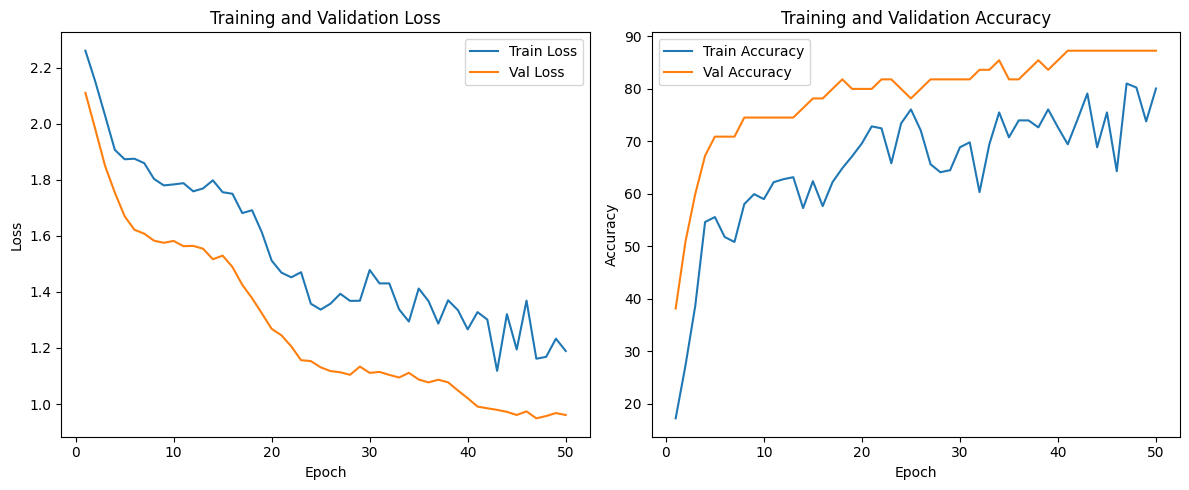

In [21]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss'])+1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy 
plt.subplot(1,2,2)
plt.plot(epochs_range, [x*100 for x in history['train_acc']], label='Train Accuracy')
plt.plot(epochs_range, [x*100 for x in history['val_acc']], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [22]:
def compute_train_acc(model, train_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device); labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

train_acc = compute_train_acc(model, train_loader, device)
print(f"Train Acc: {train_acc*100:.2f}%")


Train Acc: 85.39%


In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [24]:
cm = confusion_matrix(all_labels, all_preds)


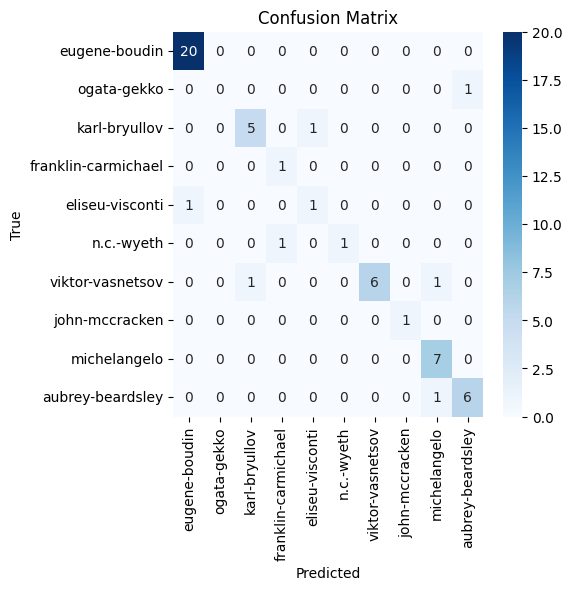

In [25]:
idx2artist = {v: k for k, v in artist2idx.items()}
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx2artist[i] for i in range(len(idx2artist))],
            yticklabels=[idx2artist[i] for i in range(len(idx2artist))])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

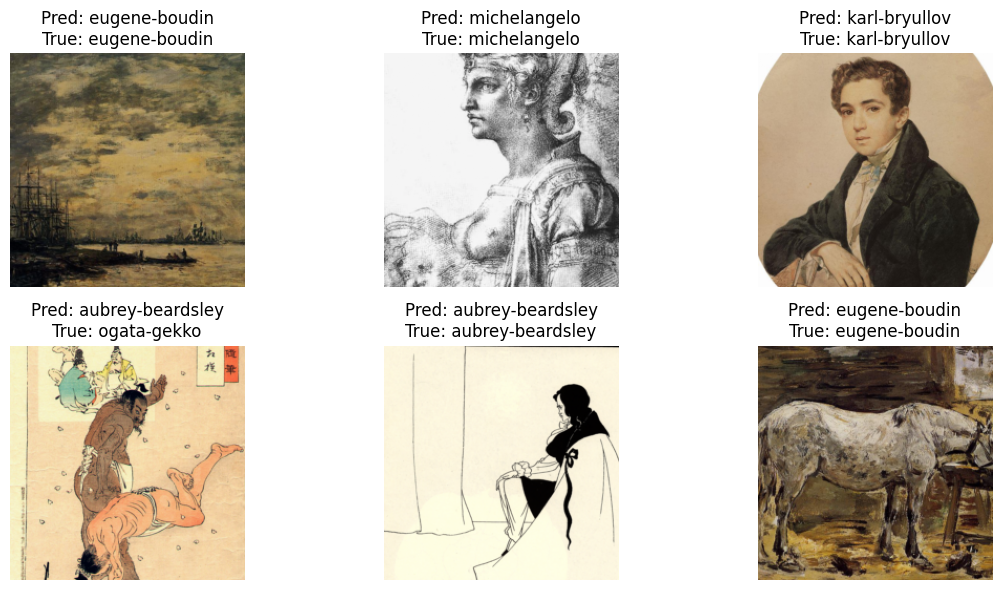

In [27]:
import torch
import matplotlib.pyplot as plt

model.eval()


images, labels = next(iter(val_loader))
images = images.to(device)
labels = labels.to(device)


with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)


idx2artist = {v:k for k,v in artist2idx.items()}

num_images = min(6, images.size(0))
plt.figure(figsize=(12,6))

for i in range(num_images):
    img = images[i].cpu()
    
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    
    img = img.permute(1,2,0).clamp(0,1)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {idx2artist[preds[i].item()]}\nTrue: {idx2artist[labels[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
